# SEMANA 10: ANÁLISIS DE CONGLOMERADOS

##  1. Con base de la información de la base de datos ‘vehículos’ la cual contiene información sobre diferentes modelos con las características más importantes que los definen, haga lo siguiente:

### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las variables numéricas y dumización para las variables categóricas. Además, elimine las variables ‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.

In [2]:
import pandas as pd
df=pd.read_csv("vehículos.csv")
df

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,smart,fortwo coupe,2015,1.0,3.0,Automatic (AM5),Rear-Wheel Drive,Two Seaters,Premium,36,244.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.105150
36787,smart,fortwo coupe,2016,0.9,3.0,Automatic (AM6),Rear-Wheel Drive,Two Seaters,Premium,35,246.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155
36788,smart,fortwo coupe,2016,0.9,3.0,Manual 5-spd,Rear-Wheel Drive,Two Seaters,Premium,34,255.000000,Coches pequeños,dos,Manual,Premium,muy pequeño,muy bajo,muy bajo,0.111336
36789,smart,fortwo coupe,2017,0.9,3.0,Automatic (AM6),Rear-Wheel Drive,Two Seaters,Premium,35,248.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155


In [5]:
columnas_a_eliminar = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
df.drop(columns=columnas_a_eliminar, inplace=True)
df

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588
...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2015,1.0,3.0,244.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.105150
36787,2016,0.9,3.0,246.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155
36788,2016,0.9,3.0,255.000000,Coches pequeños,dos,Manual,Premium,muy pequeño,muy bajo,muy bajo,0.111336
36789,2017,0.9,3.0,248.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155


In [6]:
# Análisis y tratamiento de datos faltantes
# Ver cuántos valores faltan por columna
print(df.isnull().sum())

year                    0
desplazamiento          2
cilindros               3
co2                     0
clase_tipo              0
traccion_tipo           0
transmision_tipo        0
combustible_tipo        0
tamano_motor_tipo       2
consumo_tipo            0
co2_tipo                0
consumo_litros_milla    0
dtype: int64


In [7]:
#eliminar filas con cualquier valor nulo.
df.dropna(inplace=True)
print(df.isnull().sum())

year                    0
desplazamiento          0
cilindros               0
co2                     0
clase_tipo              0
traccion_tipo           0
transmision_tipo        0
combustible_tipo        0
tamano_motor_tipo       0
consumo_tipo            0
co2_tipo                0
consumo_litros_milla    0
dtype: int64


In [9]:
# Univariado: Usamos el rango intercuartil (IQR)
import numpy as np
def eliminar_outliers_univariado(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]
    return df

columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
df = eliminar_outliers_univariado(df, columnas_numericas)


In [10]:
# Multivariado : Usamos z-score o distancia de Mahalanobis. Vamos con z-score por simplicidad.
from scipy.stats import zscore

# Calculamos z-score y filtramos
z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
df = df[(z_scores < 3).all(axis=1)]


In [11]:
# Escalamiento de variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columnas_numericas = df.select_dtypes(include=np.number).columns

df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])


In [13]:
# Dumificación de variables categóricas    
columnas_categoricas = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
df


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,-1.633556,-0.552361,-1.022992,0.640589,0.656097,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,-1.633556,0.798144,0.292782,2.258039,2.279856,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,-1.536873,-0.552361,-1.022992,0.969133,0.985923,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,-1.536873,0.798144,0.292782,2.258039,2.279856,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,-1.343509,0.480378,0.292782,0.969133,0.985923,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,1.363595,-1.743982,-1.680879,-2.162558,-2.129099,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,True
36787,1.460277,-1.823424,-1.680879,-2.142447,-2.057899,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,True
36788,1.460277,-1.823424,-1.680879,-2.051947,-1.982510,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,True
36789,1.556959,-1.823424,-1.680879,-2.122336,-2.057899,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,True


#### Durante este trabajo realicé un proceso completo de preprocesamiento de datos aplicado a un conjunto de información de vehículos. Comencé eliminando columnas irrelevantes como el fabricante, modelo, transmisión, tracción y otras variables que no aportaban valor directo al análisis. Luego, identifiqué y traté los datos faltantes eliminando registros incompletos para asegurar la calidad de los datos. A nivel univariado, detecté y eliminé outliers utilizando el rango intercuartílico (IQR), y posteriormente a nivel multivariado, utilicé el z-score para filtrar valores atípicos extremos que pudieran distorsionar el análisis. Para dejar los datos numéricos en una escala uniforme, apliqué escalamiento estándar, lo que facilita comparaciones entre variables. Finalmente, transformé las variables categóricas en variables dummies, lo que aumentó la cantidad de columnas pero permitió que el conjunto de datos estuviera listo para modelos de machine learning. Este proceso me permitió limpiar, estandarizar y estructurar los datos de forma adecuada para un análisis más robusto y confiable.

### b. Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el método del codo para determinar la cantidad de clusters adecuados. Compare los conglomerados formados y comente sobre las características que definen a estos.

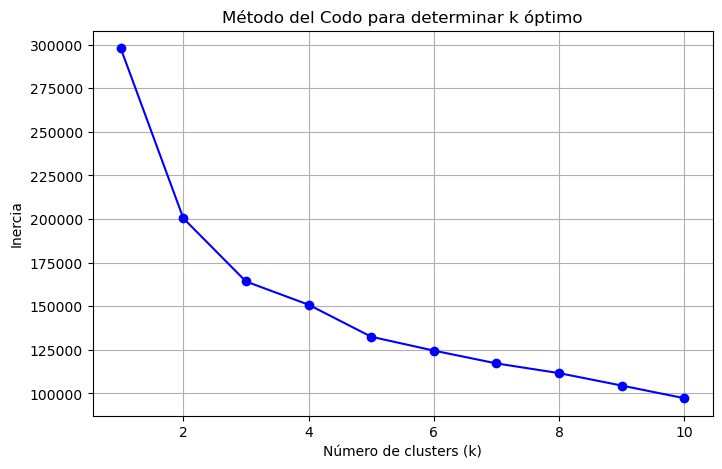

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicar el método del codo para determinar el número óptimo de clusters
inercia = []
k_rango = range(1, 11)

for k in k_rango:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inercia.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8,5))
plt.plot(k_rango, inercia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.grid(True)
plt.show()


In [15]:
# Aplicar K-Means con el número óptimo de clusters
k_optimo = 3  # Cambia esto si el codo cae en otro valor
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df['cluster'] = kmeans.fit_predict(df)


In [16]:
# Analizar los clusters formados

# Promedio de cada variable por cluster
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
print("Centros de los clusters (valores promedio por grupo):")
print(cluster_centers)

# Estadísticas por grupo
cluster_summary = df.groupby('cluster').mean()
cluster_summary


Centros de los clusters (valores promedio por grupo):
       year  desplazamiento  cilindros       co2  consumo_litros_milla  \
0 -0.143983        1.337667   1.202787  1.279332              1.262998   
1  0.043078       -0.938689  -1.000470 -0.999457             -0.997377   
2  0.054021       -0.025657   0.115278  0.065409              0.074020   

   clase_tipo_Coche Familiar  clase_tipo_Coches Grandes  \
0                   0.013925                   0.052870   
1                   0.117854                   0.011548   
2                   0.070187                   0.076778   

   clase_tipo_Coches Medianos  clase_tipo_Coches pequeños  \
0                    0.049021                    0.123627   
1                    0.120066                    0.560688   
2                    0.158554                    0.317760   

   clase_tipo_Deportivos  ...  tamano_motor_tipo_muy pequeño  \
0               0.191328  ...                  -3.858025e-15   
1               0.115725  ...          

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.144000,1.338061,1.203325,1.280317,1.263945,0.013942,0.052596,0.049082,0.123668,0.191453,...,0.000000,0.004874,0.011109,0.101678,0.561891,0.000000,0.005668,0.078214,0.601904,0.000000
1,0.043078,-0.938689,-1.000470,-0.999457,-0.997377,0.117854,0.011548,0.120066,0.560688,0.115725,...,0.630713,0.347420,0.387551,0.002539,0.000000,0.608518,0.397871,0.005651,0.000000,0.595086
2,0.053874,-0.024823,0.115800,0.065746,0.074362,0.070131,0.076934,0.158428,0.317580,0.153507,...,0.034957,0.171094,0.192299,0.661649,0.002244,0.011797,0.178838,0.676775,0.002244,0.003691


#### Luego de aplicar el algoritmo K-Means con tres clusters, logré identificar tres grupos bien diferenciados de vehículos según sus características técnicas y categóricas. El primer grupo (cluster 0) se caracteriza por vehículos con motores grandes, mayor cilindrada y número de cilindros, lo que se traduce en altos niveles de consumo de combustible y emisiones de CO₂; en su mayoría son coches deportivos o grandes. El segundo grupo (cluster 1) incluye vehículos pequeños y eficientes, con bajos niveles de consumo y emisiones, donde predominan los coches urbanos o compactos. Finalmente, el tercer grupo (cluster 2) representa un punto intermedio, con autos medianos y familiares que presentan un equilibrio entre rendimiento y eficiencia. Esta segmentación permitió comprender mejor los perfiles de vehículos presentes en los datos y ofrece una base útil para futuros análisis ambientales o de mercado.



### c. Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos.También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable ‘clase_tipo’.

In [17]:
# Medidas de evaluación interna (sin conocer clases reales)
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Datos sin la columna de cluster
X = df.drop(columns=['cluster'])

# Reaplicamos KMeans con 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42)
labels_3 = kmeans_3.fit_predict(X)

# Métricas internas
silhouette = silhouette_score(X, labels_3)
calinski = calinski_harabasz_score(X, labels_3)
davies = davies_bouldin_score(X, labels_3)

print("Evaluación Interna (K=3):")
print(f"→ Silhouette Score: {silhouette:.3f}")
print(f"→ Calinski-Harabasz Index: {calinski:.3f}")
print(f"→ Davies-Bouldin Index: {davies:.3f}")


Evaluación Interna (K=3):
→ Silhouette Score: 0.228
→ Calinski-Harabasz Index: 14185.894
→ Davies-Bouldin Index: 1.583


In [18]:
# Volver a cargar el dataset original (para recuperar clase_tipo)
df_original = pd.read_csv("vehículos.csv")
df['clase_tipo'] = df_original.loc[df.index, 'clase_tipo']  # recuperamos solo esa columna


In [19]:
# Medidas de evaluación externa (con etiquetas conocidas)    
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# KMeans con 8 clusters y evaluación externa
# Codificamos la variable de clase verdadera
le = LabelEncoder()
y_true = le.fit_transform(df['clase_tipo'])

# Aplicamos KMeans con 8 clusters
kmeans_8 = KMeans(n_clusters=8, random_state=42)
labels_8 = kmeans_8.fit_predict(df.drop(columns=['clase_tipo']))

# Métricas externas
ari = adjusted_rand_score(y_true, labels_8)
nmi = normalized_mutual_info_score(y_true, labels_8)

print("Evaluación Externa (K=8 comparado con 'clase_tipo'):")
print(f"→ ARI (Adjusted Rand Index): {ari:.3f}")
print(f"→ NMI (Normalized Mutual Information): {nmi:.3f}")


Evaluación Externa (K=8 comparado con 'clase_tipo'):
→ ARI (Adjusted Rand Index): 0.104
→ NMI (Normalized Mutual Information): 0.155


#### Los resultados obtenidos al evaluar los clusters formados con K-Means (K=8) en comparación con la variable clase_tipo muestran una correspondencia baja entre ambos. El Adjusted Rand Index (ARI) de 0.104 y el Normalized Mutual Information (NMI) de 0.155 indican que los clusters generados no coinciden significativamente con las categorías reales. Estos valores sugieren que, aunque el algoritmo de K-Means ha segmentado los datos en grupos, dichos grupos no reflejan bien las clases originales. Esto podría deberse a que las características utilizadas para el clustering no capturan adecuadamente la estructura subyacente de las clases o a que K-Means está identificando patrones diferentes a los definidos por clase_tipo. En resumen, aunque los clusters generados pueden ser útiles en algunos contextos, no se alinean de manera efectiva con las categorías predefinidas en los datos.